# Exploratory Data Analysis of the Uscreen Client

# 1. Task Description 

### 1.1. Data Description

This dataset represents all successful subscription transactions for one of our customer’s stores covering a one-year period from April 2022 through March 2023.
- invoice_id: unique identifier for the subscription invoice
- user_id: unique identifier for the customer purchasing the subscription. NOTE: one user can have multiple invoices, and can subscribe to different plans
- plan_id: unique identifier for the subscription plan offered by the store
- plan_duration: the length of the purchased subscription period (Monthly or Annual)
- transaction_date: date that the invoice was paid
- subscription_price: initial price (in US dollars ) on the invoice
- discount_applied: the amount (in US dollars) of any discounts or coupons applied to the subscription price
- fees_charged: the amount (in US dollars) charged in fees on the invoice, including but not limited to subscriber fees charged by Uscreen and/or fees charged for payment processing by a third-party vendor such as Stripe
- amount_paid: the amount (in US dollars) that the store receives for the subscription payment. NOTE: use this field when calculating revenue


### 1.2. Research Plan

1. Upload and prepare Data for analysis
2. Make EDA: build reports, calculate metrcis, answer the questions
3. Write suggestions for the client

# 2. Upload and Prepare Data for Analysis

## 2.1. Upload libraries and Data

In [1]:
# libraries 
import pandas as pd
import numpy as np
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

In [2]:
# csv file
path = 'data.csv'
df = pd.read_csv(path, sep = ';')

In [3]:
df.head()

,invoice_id,user_id,plan_id,plan_duration,transaction_date,subscription_price,discount_applied,fees_charged,amount_paid
0,ALNtNdnZ5g,jpvAY4jgqX,3ZksraziGv,Monthly,2022-04-01,"$30,00","$0,00","$1,67","$28,33"
1,UB/p3I3soC,7lnc9S0e+k,3ZksraziGv,Monthly,2022-04-01,"$30,00","$0,00","$1,97","$28,03"
2,JPqaABdS9/,rSRvTF4HKP,3ZksraziGv,Monthly,2022-04-01,"$30,00","$0,00","$1,67","$28,33"
3,qFP1t+jHi2,2P8ziCzzMW,3ZksraziGv,Monthly,2022-04-01,"$30,00","$0,00","$1,67","$28,33"
4,/RBlpp5X7q,i677ChXxOx,3ZksraziGv,Monthly,2022-04-01,"$30,00","$0,00","$1,67","$28,33"


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16009 entries, 0 to 16008
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   invoice_id          16007 non-null  str  
 1   user_id             16007 non-null  str  
 2   plan_id             16007 non-null  str  
 3   plan_duration       16007 non-null  str  
 4   transaction_date    16007 non-null  str  
 5   subscription_price  16007 non-null  str  
 6   discount_applied    16007 non-null  str  
 7   fees_charged        16007 non-null  str  
 8   amount_paid         16007 non-null  str  
dtypes: str(9)
memory usage: 1.1 MB


## 2.2. Data Preprocessing

In [5]:
# change type of the column "date" from string to date 
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [6]:
# change type of the columns "subscription_price", "discount_applied", "fees_charged", "amount_paid"
# from string to float, plus remove symbol $ 

for i in ["subscription_price", "discount_applied", "fees_charged", "amount_paid"]:
    df[i] = df[i].str.replace('$', '').str.replace(',', '.').astype('float')

In [7]:
# check null values
for i in df.columns:
    print('column', i, 'has', len(df[df[i].isna()]), 'null values')

column invoice_id has 2 null values
column user_id has 2 null values
column plan_id has 2 null values
column plan_duration has 2 null values
column transaction_date has 2 null values
column subscription_price has 2 null values
column discount_applied has 2 null values
column fees_charged has 2 null values
column amount_paid has 2 null values


In [8]:
# check duplicates
df[df.duplicated()]

,invoice_id,user_id,plan_id,plan_duration,transaction_date,subscription_price,discount_applied,fees_charged,amount_paid
16008,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN


In [9]:
# remove 2 null rows, which are also duplicated
df = df.dropna()

In [10]:
# check correct count of plan_id and plan_duration
df.groupby(['plan_duration', 'plan_id']).agg({'plan_duration':'count', 'plan_id':'count'})

,,plan_duration,plan_id
plan_duration,plan_id,,
Annual,4tWDsR5/vb,874,874
Monthly,3ZksraziGv,15133,15133


In [11]:
# check unique and total amoun of the invoices
df['invoice_id'].nunique(), df['invoice_id'].count()

(16007, np.int64(16007))

In [12]:
# check unique users and number of purchases
df['user_id'].nunique(), df['user_id'].count()

(3619, np.int64(16007))

In [13]:
# check negavite values
for i in ['subscription_price', 'discount_applied', 'fees_charged', 'amount_paid']:
    for j in df[i]:
        if j < 0:
            print(i, j)

fees_charged -30.0
fees_charged -30.0
fees_charged -30.0
fees_charged -30.0
fees_charged -30.0
fees_charged -30.0


In [14]:
# remove these rows
df = df[df['fees_charged'] != -30.0]

### Stage 2 Summary:
1. We performed preprocessing actions on the data, which involved removing null values, negative fee values, duplicates, changing data types, and removing currency symbols. 

2. It's important for the development and product teams to consider how the null values may have been created in the database, whether by human error, machine malfunction, or a combination of factors. 

3. Similarly, it's crucial to investigate the regular occurrence of negative fees and determine the underlying reason.

# 3. Exploratory Data Analysis

Main Questions:
- What kind of subscriptions does client use? What is the price of subscriptions?
- How are different subscriptions distributed by month?
- How much money does client make from subscriptions?
- What discounts apply? Which subscriptions are most often discounted? What percentage of the subscription cost is the discount?
- Are there users who switched from one subscription to another? monthly to annual, annual to monthly. After how many months?
- What are the applicable fees?

**Q1: What kind of subscriptions does client use? What is the price of subscriptions?**

In [15]:
# check subscription prices
prices = df.groupby(['subscription_price', 'plan_duration']).invoice_id.count().reset_index()
prices = prices.rename(columns = {"invoice_id":"invoice_amount"})
prices

,subscription_price,plan_duration,invoice_amount
0,30.0,Monthly,15127
1,275.0,Annual,874


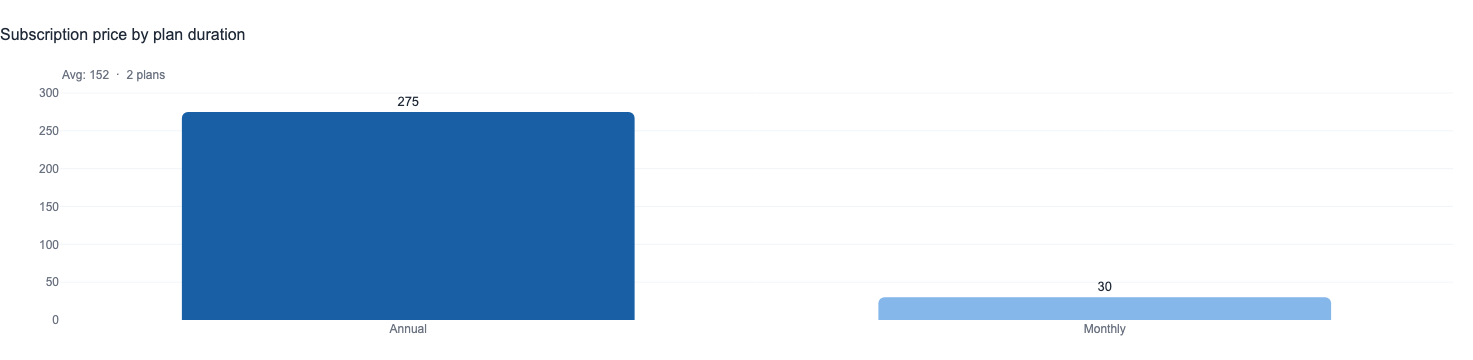

In [16]:
df_prices_chart = prices[['plan_duration', 'subscription_price']].copy()
df_prices_chart = df_prices_chart.sort_values('subscription_price', ascending=False)

max_val = df_prices_chart['subscription_price'].max()

# Color intensity based on value (darker = higher)
def get_color(val):
    ratio = val / max_val
    if ratio >= 0.85: return '#185FA5'
    if ratio >= 0.60: return '#378ADD'
    if ratio >= 0.35: return '#5BA3E8'
    return '#85B7EB'

colors = [get_color(v) for v in df_prices_chart['subscription_price']]

fig = go.Figure(go.Bar(
    x=df_prices_chart['plan_duration'],
    y=df_prices_chart['subscription_price'],
    text=df_prices_chart['subscription_price'].apply(lambda v: f'{v:,.0f}'),
    textposition='outside',
    marker=dict(
        color=colors,
        line_width=0,
        cornerradius=6,
    ),
    cliponaxis=False,
))

avg = df_prices_chart['subscription_price'].mean()

fig.update_layout(
    title=dict(
        text='Subscription price by plan duration',
        font=dict(size=16, color='#1f2937', family='Arial'),
        x=0,
        pad=dict(b=16)
    ),
    annotations=[
        dict(
            text=f"Avg: {avg:,.0f}  ·  {len(df_prices_chart)} plans",
            xref='paper', yref='paper', x=0, y=1.06,
            showarrow=False,
            font=dict(size=12, color='#6b7280', family='Arial'),
            align='left'
        )
    ],
    xaxis=dict(
        title=None,
        showgrid=False,
        tickfont=dict(size=12, color='#6b7280', family='Arial'),
        showline=False,
    ),
    yaxis=dict(
        title=None,
        showgrid=True,
        gridcolor='#f1f5f9',
        gridwidth=1,
        zeroline=False,
        tickfont=dict(size=12, color='#6b7280', family='Arial'),
        tickformat=',.0f',
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    font=dict(family='Arial', size=13, color='#1f2937'),
    margin=dict(t=80, b=40, l=60, r=20),
    bargap=0.35,
)

fig.show()

**Q2: How are different subscriptions distributed by month?**

In [17]:
df['transaction_month'] = df['transaction_date'].dt.to_period('M')

In [18]:
df['transaction_month'] = df['transaction_month'].astype(str)  # add this line

subs_m = df.pivot_table(index='transaction_month',
                        columns='plan_duration', 
                        values='invoice_id', 
                        aggfunc='count').reset_index()

subs_m['total'] = subs_m['Annual'] + subs_m['Monthly']
subs_m

plan_duration,transaction_month,Annual,Monthly,total
0,2022-04,26,1274,1300
1,2022-05,36,1232,1268
2,2022-06,16,1228,1244
3,2022-07,25,1234,1259
4,2022-08,31,1221,1252
5,2022-09,65,1206,1271
6,2022-10,49,1182,1231
7,2022-11,65,1248,1313
8,2022-12,174,1291,1465
9,2023-01,265,1325,1590


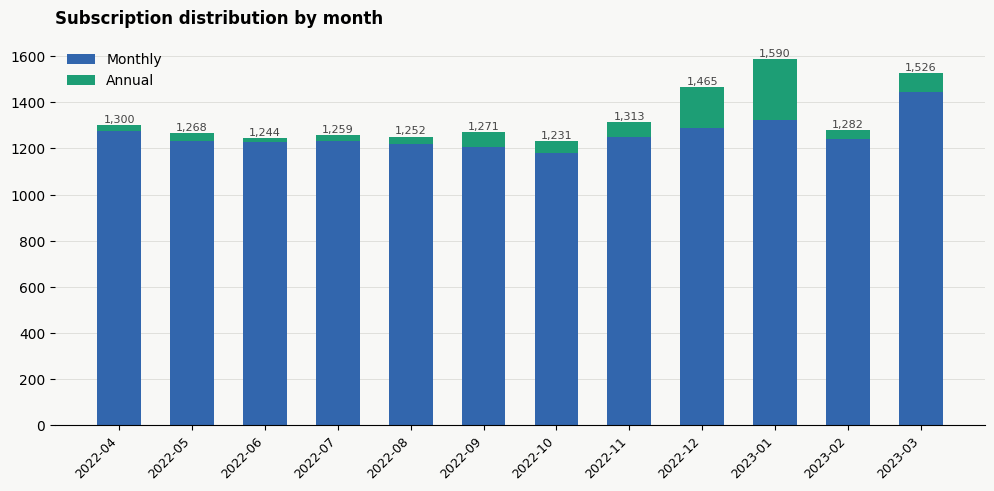

In [19]:
months  = subs_m['transaction_month'].astype(str).tolist()
monthly = subs_m['Monthly'].fillna(0).tolist()
annual  = subs_m['Annual'].fillna(0).tolist()
totals  = subs_m['total'].tolist()

x = np.arange(len(months))

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#f8f8f6')
ax.set_facecolor('#f8f8f6')

ax.bar(x, monthly, color='#3266ad', label='Monthly', width=0.6)
ax.bar(x, annual,  color='#1D9E75', label='Annual',  width=0.6, bottom=monthly)

for i, tot in enumerate(totals):
    ax.text(i, tot + 2, f'{int(tot):,}', ha='center', va='bottom', fontsize=8, color='#444')

ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha='right', fontsize=9)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.grid(True, color='#e0e0dc', linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(frameon=False)
ax.set_title('Subscription distribution by month', fontsize=12, fontweight='bold', loc='left', pad=12)

plt.show()

**Q3: How much money does client make from subscriptions?**

In [20]:
# total
df['amount_paid'].sum()

np.float64(625539.69)

In [21]:
# total revenue via Subscription Type
total_rev = df.groupby('plan_duration').amount_paid.sum().reset_index()
total_rev

,plan_duration,amount_paid
0,Annual,203501.66
1,Monthly,422038.03


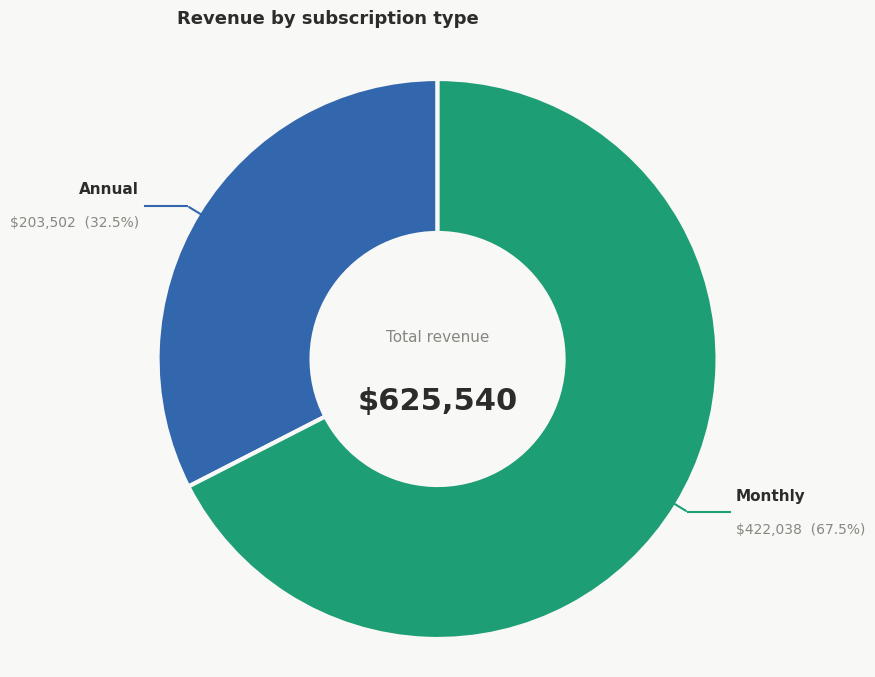

In [22]:
labels = total_rev['plan_duration'].tolist()
sizes  = total_rev['amount_paid'].tolist()
total  = sum(sizes)

COLORS  = ['#3266ad', '#1D9E75']
BG      = '#f8f8f6'
C_TEXT  = '#2C2C2A'
C_MUTED = '#888780'

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

wedges, _ = ax.pie(
    sizes,
    colors=COLORS,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=3),  # donut
    pctdistance=0.75,
)

# center text
ax.text(0, 0.08, 'Total revenue', ha='center', va='center',
        fontsize=11, color=C_MUTED)
ax.text(0, -0.15, f'${total:,.0f}', ha='center', va='center',
        fontsize=22, fontweight='bold', color=C_TEXT)

# custom outer labels with lines
for i, (wedge, label, size) in enumerate(zip(wedges, labels, sizes)):
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)
    x1, y1 = 0.65 * np.cos(rad), 0.65 * np.sin(rad)   # inner point
    x2, y2 = 1.05 * np.cos(rad), 1.05 * np.sin(rad)   # outer point
    x3     = x2 + (0.15 if x2 > 0 else -0.15)          # text anchor

    ax.annotate(
        '',
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='-', color=COLORS[i], lw=1.5)
    )
    ax.plot([x2, x3], [y2, y2], color=COLORS[i], lw=1.5)

    ha = 'left' if x2 > 0 else 'right'
    pct = size / total * 100
    ax.text(x3 + (0.02 if x2 > 0 else -0.02), y2 + 0.06,
            label, ha=ha, va='center', fontsize=11,
            fontweight='bold', color=C_TEXT)
    ax.text(x3 + (0.02 if x2 > 0 else -0.02), y2 - 0.06,
            f'${size:,.0f}  ({pct:.1f}%)', ha=ha, va='center',
            fontsize=10, color=C_MUTED)

ax.set_title('Revenue by subscription type', fontsize=13,
             fontweight='bold', color=C_TEXT, pad=20, loc='left',
             x=0.08)

ax.set_xlim(-1.6, 1.6)
ax.axis('equal')
plt.show()

In [23]:
df['transaction_month'] = pd.to_datetime(df['transaction_month'].astype(str))

subs_m_rev = df.pivot_table(index='transaction_month',
                             columns='plan_duration',
                             values='amount_paid',
                             aggfunc='sum').reset_index()

subs_m_rev['total_revenue'] = subs_m_rev['Annual'] + subs_m_rev['Monthly']
subs_m_rev['year_month'] = subs_m_rev['transaction_month'].dt.strftime('%Y_%m')
subs_m_rev

plan_duration,transaction_month,Annual,Monthly,total_revenue,year_month
0,2022-04-01,5359.63,35634.02,40993.65,2022_04
1,2022-05-01,7615.12,34154.33,41769.45,2022_05
2,2022-06-01,3493.31,34241.36,37734.67,2022_06
3,2022-07-01,5421.96,34537.60,39959.56,2022_07
4,2022-08-01,6474.97,34227.90,40702.87,2022_08
5,2022-09-01,15026.12,33765.85,48791.97,2022_09
6,2022-10-01,10869.90,33182.37,44052.27,2022_10
7,2022-11-01,14358.84,34941.31,49300.15,2022_11
8,2022-12-01,39280.52,36094.92,75375.44,2022_12
9,2023-01-01,65784.84,37125.32,102910.16,2023_01


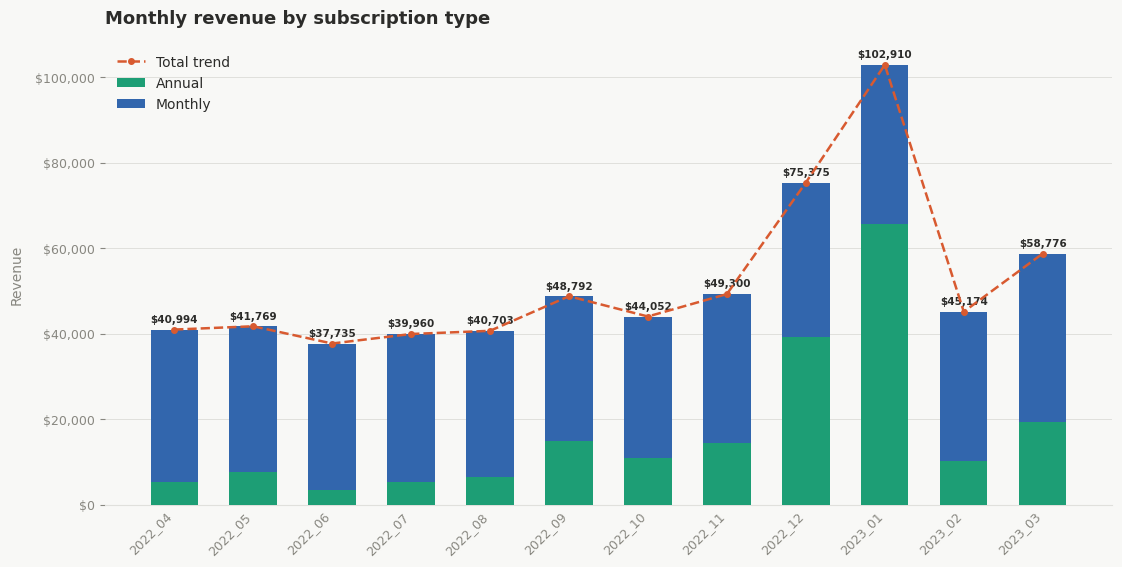

In [24]:
months  = subs_m_rev['year_month'].astype(str).tolist()
annual  = subs_m_rev['Annual'].fillna(0).tolist()
monthly = subs_m_rev['Monthly'].fillna(0).tolist()
totals  = [a + m for a, m in zip(annual, monthly)]

x      = np.arange(len(months))
BG     = '#f8f8f6'
C_TEXT = '#2C2C2A'
C_MUTED= '#888780'
C_GRID = '#e0e0dc'
C_ANN  = '#1D9E75'
C_MON  = '#3266ad'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.bar(x, annual,  width=0.6, color=C_ANN, label='Annual',  zorder=3)
ax.bar(x, monthly, width=0.6, color=C_MON, label='Monthly', bottom=annual, zorder=3)

# total labels
for i, tot in enumerate(totals):
    ax.text(i, tot + max(totals) * 0.012, f'${tot:,.0f}',
            ha='center', va='bottom', fontsize=7.5,
            fontweight='bold', color=C_TEXT)

# trend line on totals
ax.plot(x, totals, color='#D85A30', linewidth=1.8,
        linestyle='--', marker='o', markersize=4,
        zorder=4, label='Total trend')

ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha='right', fontsize=9, color=C_MUTED)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.tick_params(axis='y', labelsize=9, colors=C_MUTED)
ax.tick_params(axis='x', length=0)
ax.set_ylabel('Revenue', fontsize=10, color=C_MUTED, labelpad=8)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(C_GRID)
ax.yaxis.grid(True, color=C_GRID, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

ax.legend(frameon=False, fontsize=10, labelcolor=C_TEXT, loc='upper left')
ax.set_title('Monthly revenue by subscription type', fontsize=13,
             fontweight='bold', color=C_TEXT, pad=14, loc='left')

plt.show()

**Q4: What discounts apply? Which subscriptions are most often discounted? What percentage of the subscription cost is the discount?**

In [25]:
df['discount_bigger_zero'] = df['discount_applied'].apply(lambda x: 1 if x > 0 else 0)

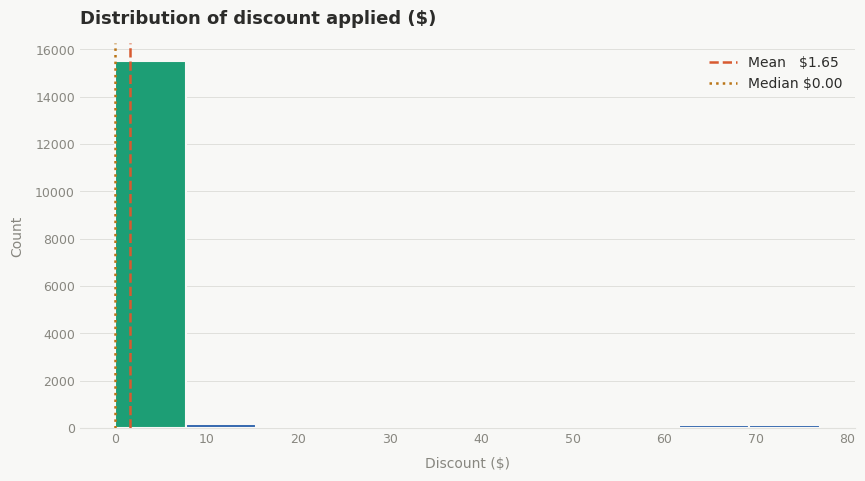

In [26]:
data   = df['discount_applied'].dropna()
BG     = '#f8f8f6'
C_TEXT = '#2C2C2A'
C_MUTED= '#888780'
C_GRID = '#e0e0dc'
C_BAR  = '#3266ad'

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

n, bins, patches = ax.hist(data, bins=10, color=C_BAR,
                            edgecolor=BG, linewidth=1.5, zorder=3)

# color the tallest bar as accent
patches[np.argmax(n)].set_facecolor('#1D9E75')

# mean & median lines
ax.axvline(data.mean(),   color='#D85A30', linewidth=1.8,
           linestyle='--', zorder=4, label=f'Mean   ${data.mean():.2f}')
ax.axvline(data.median(), color='#BA7517', linewidth=1.8,
           linestyle=':',  zorder=4, label=f'Median ${data.median():.2f}')

ax.set_xlabel('Discount ($)', fontsize=10, color=C_MUTED, labelpad=8)
ax.set_ylabel('Count',        fontsize=10, color=C_MUTED, labelpad=8)
ax.tick_params(labelsize=9, colors=C_MUTED, length=0)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(C_GRID)
ax.yaxis.grid(True, color=C_GRID, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

ax.legend(frameon=False, fontsize=10, labelcolor=C_TEXT)
ax.set_title('Distribution of discount applied ($)', fontsize=13,
             fontweight='bold', color=C_TEXT, pad=14, loc='left')

plt.show()

In [27]:
# what is the perc of subs with discounts?
discounts = (df
                .groupby('plan_duration')
                .agg({'invoice_id':'count', 'discount_bigger_zero':'sum'})
                .reset_index()
            )

discounts = discounts.rename(columns = {"invoice_id":"total_invoices", "discount_bigger_zero":"invoices_with_discount"})
discounts['perc_invoices_with_discount'] = round(discounts['invoices_with_discount'] / discounts['total_invoices'] * 100,2)
discounts

,plan_duration,total_invoices,invoices_with_discount,perc_invoices_with_discount
0,Annual,874,325,37.19
1,Monthly,15127,337,2.23


In [28]:
# what is the perc of subs with discounts in dollars? NEED UPDATE
discounts_sum = (df            
                    .groupby('plan_duration')
                    .agg({'subscription_price':'sum', 'discount_applied':'sum'})
                    .reset_index()
                )

discounts_sum = discounts_sum.rename(columns = {"subscription_price":"sub_total_price", "discount_applied":"sub_total_discounts"})
discounts_sum['perc_of_discounts'] = round(discounts_sum['sub_total_discounts'] / discounts_sum['sub_total_price'] * 100,2)
discounts_sum

,plan_duration,sub_total_price,sub_total_discounts,perc_of_discounts
0,Annual,240350.0,23144.0,9.63
1,Monthly,453810.0,3236.0,0.71


In [29]:
# What months are the most discounted?
df_discounts = (df[(df['discount_bigger_zero'] == 1)]
                    .pivot_table(index = 'transaction_month', 
                                 columns = 'plan_duration', 
                                 values = 'invoice_id', 
                                 aggfunc = 'count').reset_index()
               )

df_discounts

plan_duration,transaction_month,Annual,Monthly
0,2022-04-01,19,10
1,2022-05-01,23,32
2,2022-06-01,9,20
3,2022-07-01,14,16
4,2022-08-01,20,11
5,2022-09-01,23,17
6,2022-10-01,24,8
7,2022-11-01,34,17
8,2022-12-01,86,20
9,2023-01-01,40,24


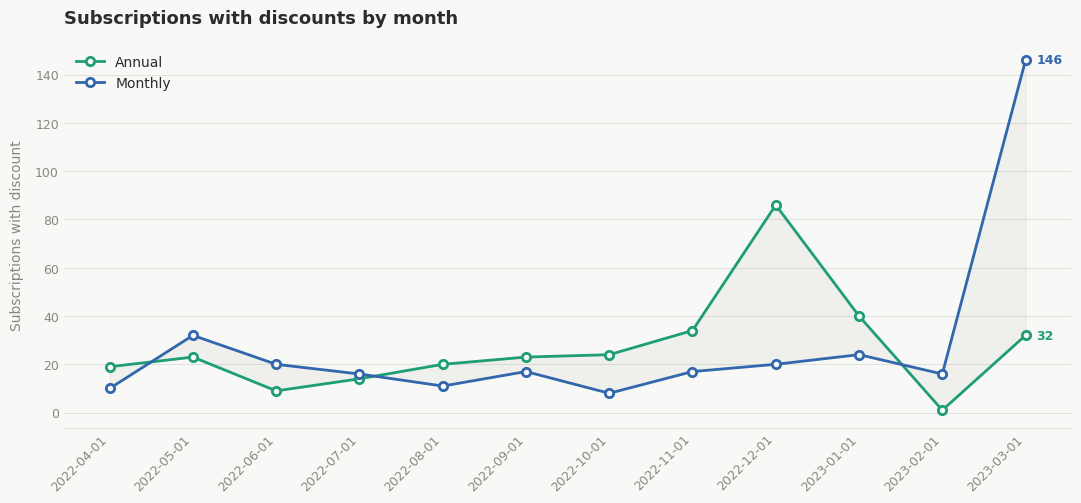

In [30]:
x  = df_discounts['transaction_month'].astype(str).tolist()
y1 = df_discounts['Annual'].fillna(0).tolist()
y2 = df_discounts['Monthly'].fillna(0).tolist()

BG      = '#f8f8f6'
C_TEXT  = '#2C2C2A'
C_MUTED = '#888780'
C_GRID  = '#e0e0dc'
C_ANN   = '#1D9E75'
C_MON   = '#3266ad'

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(x, y1, color=C_ANN, linewidth=2, marker='o',
        markersize=6, markerfacecolor=BG, markeredgewidth=2,
        label='Annual', zorder=3)
ax.plot(x, y2, color=C_MON, linewidth=2, marker='o',
        markersize=6, markerfacecolor=BG, markeredgewidth=2,
        label='Monthly', zorder=3)

# shaded area between the two lines
ax.fill_between(x, y1, y2, alpha=0.08, color='#888780', zorder=2)

# annotate last data point of each line
for y, color, label in [(y1, C_ANN, 'Annual'), (y2, C_MON, 'Monthly')]:
    ax.annotate(f'{int(y[-1])}',
                xy=(len(x)-1, y[-1]),
                xytext=(8, 0), textcoords='offset points',
                va='center', fontsize=9,
                fontweight='bold', color=color)

ax.set_xticks(range(len(x)))
ax.set_xticklabels(x, rotation=45, ha='right', fontsize=9, color=C_MUTED)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.tick_params(axis='y', labelsize=9, colors=C_MUTED, length=0)
ax.tick_params(axis='x', length=0)
ax.set_ylabel('Subscriptions with discount', fontsize=10, color=C_MUTED, labelpad=8)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(C_GRID)
ax.yaxis.grid(True, color=C_GRID, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

ax.legend(frameon=False, fontsize=10, labelcolor=C_TEXT, loc='upper left')
ax.set_title('Subscriptions with discounts by month', fontsize=13,
             fontweight='bold', color=C_TEXT, pad=14, loc='left')
plt.show()

In [31]:
# Popular discounts with Annual Subscription
annual_discounts = df[(df['discount_bigger_zero'] == 1) & (df['plan_duration'] == 'Annual')]['discount_applied'].value_counts().reset_index()
annual_discounts.columns = ['annual_discount_applied_usd', 'amount']
annual_discounts

,annual_discount_applied_usd,amount
0,68.75,148
1,77.00,147
2,55.00,30


In [32]:
# Popular discounts with Monthly Subscription
monthly_discounts = df[(df['discount_bigger_zero'] == 1) & (df['plan_duration'] == 'Monthly')]['discount_applied'].value_counts().reset_index()
monthly_discounts.columns = ['month_discount_applied_usd', 'amount']
monthly_discounts

,month_discount_applied_usd,amount
0,7.5,136
1,10.0,119
2,15.0,65
3,3.0,17


In [33]:
# distribution of monthly subs with discounts
discounts_sum_monthly = (
    df[df['plan_duration'] == 'Monthly']
    .groupby('transaction_month')
    .agg({'invoice_id':'count', 'discount_bigger_zero':'sum'})
    .reset_index()
            )

discounts_sum_monthly = discounts_sum_monthly.rename(columns = {"invoice_id":"sub_total_price", "discount_bigger_zero":"sub_total_discounts"})
discounts_sum_monthly['ratio'] = round(discounts_sum_monthly['sub_total_discounts'] / discounts_sum_monthly['sub_total_price'] * 100,2)
discounts_sum_monthly

,transaction_month,sub_total_price,sub_total_discounts,ratio
0,2022-04-01,1274,10,0.78
1,2022-05-01,1232,32,2.60
2,2022-06-01,1228,20,1.63
3,2022-07-01,1234,16,1.30
4,2022-08-01,1221,11,0.90
5,2022-09-01,1206,17,1.41
6,2022-10-01,1182,8,0.68
7,2022-11-01,1248,17,1.36
8,2022-12-01,1291,20,1.55
9,2023-01-01,1325,24,1.81


In [34]:
# distribution of annual subs with discounts
discounts_sum_annual = (
    df[df['plan_duration'] == 'Annual']
    .groupby('transaction_month')
    .agg({'invoice_id':'count', 'discount_bigger_zero':'sum'})
    .reset_index()
            )

discounts_sum_annual = discounts_sum_annual.rename(columns = {"invoice_id":"sub_total_price", "discount_bigger_zero":"sub_total_discounts"})
discounts_sum_annual['ratio'] = round(discounts_sum_annual['sub_total_discounts'] / discounts_sum_annual['sub_total_price'] * 100,2)
discounts_sum_annual

,transaction_month,sub_total_price,sub_total_discounts,ratio
0,2022-04-01,26,19,73.08
1,2022-05-01,36,23,63.89
2,2022-06-01,16,9,56.25
3,2022-07-01,25,14,56.00
4,2022-08-01,31,20,64.52
5,2022-09-01,65,23,35.38
6,2022-10-01,49,24,48.98
7,2022-11-01,65,34,52.31
8,2022-12-01,174,86,49.43
9,2023-01-01,265,40,15.09


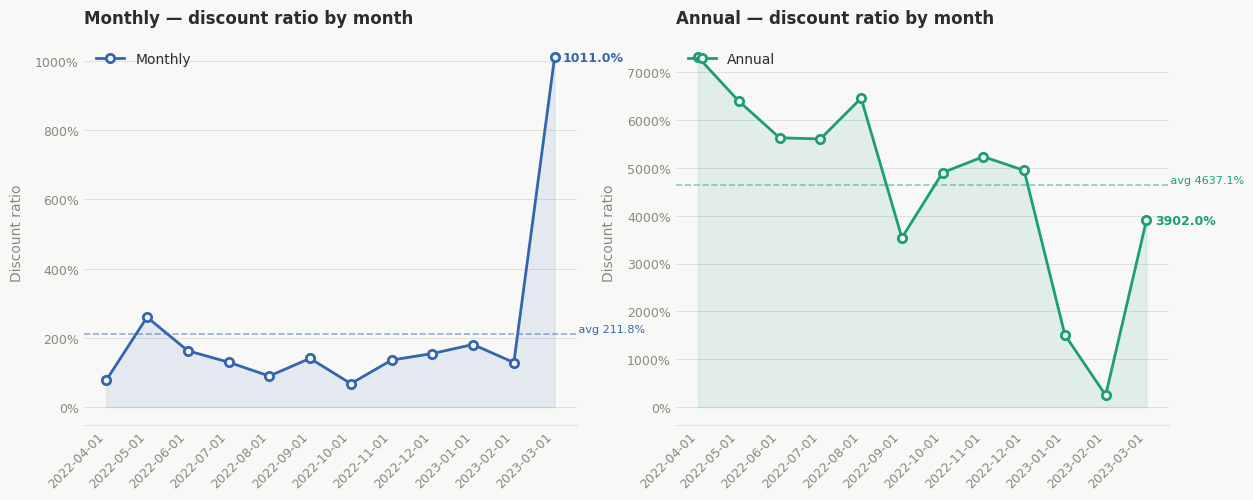

In [35]:
BG      = '#f8f8f6'
C_TEXT  = '#2C2C2A'
C_MUTED = '#888780'
C_GRID  = '#e0e0dc'
C_ANN   = '#1D9E75'
C_MON   = '#3266ad'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)

datasets = [
    (axes[0], discounts_sum_monthly, C_MON, 'Monthly'),
    (axes[1], discounts_sum_annual,  C_ANN, 'Annual'),
]

for ax, df_src, color, label in datasets:
    x = df_src['transaction_month'].astype(str).tolist()
    y = df_src['ratio'].fillna(0).tolist()

    ax.set_facecolor(BG)

    ax.fill_between(range(len(x)), y, alpha=0.1, color=color, zorder=2)
    ax.plot(range(len(x)), y, color=color, linewidth=2,
            marker='o', markersize=6,
            markerfacecolor=BG, markeredgewidth=2,
            zorder=3, label=label)

    # avg reference line
    avg = sum(y) / len(y)
    ax.axhline(avg, color=color, linewidth=1.2,
               linestyle='--', alpha=0.5, zorder=2)
    ax.text(len(x) - 0.5, avg, f' avg {avg:.1%}',
            va='bottom', fontsize=8, color=color)

    # annotate last point
    ax.annotate(f'{y[-1]:.1%}',
                xy=(len(x)-1, y[-1]),
                xytext=(6, 0), textcoords='offset points',
                va='center', fontsize=9,
                fontweight='bold', color=color)

    ax.set_xticks(range(len(x)))
    ax.set_xticklabels(x, rotation=45, ha='right', fontsize=8, color=C_MUTED)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.tick_params(labelsize=9, colors=C_MUTED, length=0)
    ax.set_ylabel('Discount ratio', fontsize=10, color=C_MUTED, labelpad=8)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color(C_GRID)
    ax.yaxis.grid(True, color=C_GRID, linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=10, labelcolor=C_TEXT, loc='upper left')
    ax.set_title(f'{label} — discount ratio by month', fontsize=12,
                 fontweight='bold', color=C_TEXT, pad=12, loc='left')

fig.suptitle('') 
plt.show()

**Q5: Are there users who switched from one subscription to another? monthly to annual, annual to monthly. After how many months?**

In [36]:
# build a table with users subscriptions
change_sub = df.pivot_table(index = 'user_id', columns = 'plan_duration', values = 'plan_id', aggfunc = 'nunique').reset_index().fillna(0)
change_sub['total'] = change_sub['Annual'] + change_sub['Monthly']
change_sub.head()

plan_duration,user_id,Annual,Monthly,total
0,++jokcWsOw,0.0,1.0,1.0
1,+0l7207r+v,0.0,1.0,1.0
2,+2hatVdqL2,0.0,1.0,1.0
3,+31qk9llgb,0.0,1.0,1.0
4,+3SY+ycrLR,0.0,1.0,1.0


In [37]:
# select users who have over 1 subscription
users_who_changed_sub = list(change_sub.query('total > 1')['user_id'])
len(users_who_changed_sub)

107

In [38]:
# filter initial table and add direction of subscription change

df_changed = df[df['user_id'].isin(users_who_changed_sub)]

df_changed_pivot = (df_changed
                    .pivot_table(index = 'user_id', 
                                 columns = 'plan_duration', 
                                 values = 'transaction_month', 
                                 aggfunc = 'max')
                   ).reset_index()

df_changed_pivot = df_changed_pivot.rename(columns = {"Annual":"max_annual_date", "Monthly":"max_monthly_date"})
df_changed_pivot.loc[df_changed_pivot['max_annual_date'] > df_changed_pivot['max_monthly_date'], 'change_direction'] = 'from monthly to annual'
df_changed_pivot.loc[df_changed_pivot['max_monthly_date'] > df_changed_pivot['max_annual_date'], 'change_direction'] = 'from annual to monthly'
df_changed_pivot.head()

plan_duration,user_id,max_annual_date,max_monthly_date,change_direction
0,0UlbpyWJzm,2022-12-01,2022-11-01,from monthly to annual
1,0hOX3dcPuv,2023-03-01,2022-08-01,from monthly to annual
2,1U2sCTwHHp,2023-02-01,2023-01-01,from monthly to annual
3,2Aa1k4IOhn,2022-11-01,2022-10-01,from monthly to annual
4,2KSraiJT3e,2022-12-01,2022-11-01,from monthly to annual


In [39]:
df_changed_pivot['change_direction'].value_counts().reset_index()

,change_direction,count
0,from monthly to annual,107


In [40]:
df_changed.groupby('user_id').invoice_id.count().mean()

np.float64(6.168224299065421)

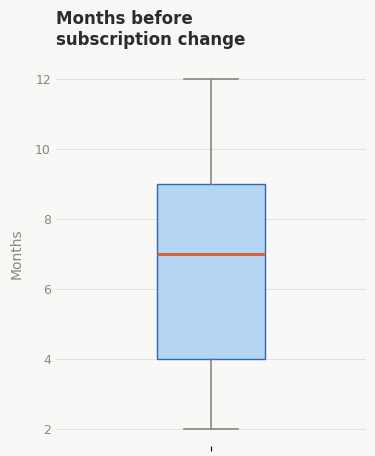

In [41]:
ch = df_changed.groupby('user_id').invoice_id.count().sort_values()

fig, ax = plt.subplots(figsize=(4, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bp = ax.boxplot(ch, widths=0.35, patch_artist=True,
                medianprops=dict(color='#D85A30', linewidth=2),
                boxprops=dict(facecolor='#B5D4F4', color=C_MON),
                whiskerprops=dict(color=C_MUTED, linewidth=1.2),
                capprops=dict(color=C_MUTED, linewidth=1.2),
                flierprops=dict(marker='o', color=C_MON,
                                markerfacecolor=BG, markersize=5))

ax.set_xticklabels([''])
ax.tick_params(axis='y', labelsize=9, colors=C_MUTED, length=0)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.yaxis.grid(True, color=C_GRID, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
ax.set_ylabel('Months', fontsize=10, color=C_MUTED, labelpad=8)
ax.set_title('Months before\nsubscription change', fontsize=12,
             fontweight='bold', color=C_TEXT, pad=12, loc='left')

plt.show()

**Q6: What are the applicable fees?**

In [42]:
df[df['fees_charged'] != 0].shape

(14483, 11)

In [43]:
# all fee values
fees_df = df.groupby(['plan_duration', 'fees_charged']).invoice_id.count().reset_index()
fees_df.columns = ['plan_duration','fees_charged', 'invoice_amount']
fees_df.sort_values(by = ['plan_duration', 'invoice_amount'], ascending = [True, False])

,plan_duration,fees_charged,invoice_amount
9,Annual,14.28,240
14,Annual,17.03,133
22,Annual,25.71,79
5,Annual,12.04,63
6,Annual,12.28,56
20,Annual,21.59,54
11,Annual,14.34,50
0,Annual,0.00,40
8,Annual,14.02,35
19,Annual,20.90,29


**1 main outburst was found: zero fees**

In [44]:
not_charged_fees = fees_df[fees_df['fees_charged'] == 0]
not_charged_fees

,plan_duration,fees_charged,invoice_amount
0,Annual,0.0,40
24,Monthly,0.0,1478


In [45]:
annual_avg_fee = df[(df['plan_duration'] == 'Annual') & (df['fees_charged'] != 0)].fees_charged.median()
annual_avg_fee

np.float64(14.28)

In [46]:
monthly_avg_fee = df[(df['plan_duration'] == 'Monthly') & (df['fees_charged'] > 0)].fees_charged.median()
monthly_avg_fee

np.float64(1.97)

In [47]:
not_charged_fees['avg_fee'] = annual_avg_fee, monthly_avg_fee
not_charged_fees['missed_revenue'] = not_charged_fees['invoice_amount'] * not_charged_fees['avg_fee']
not_charged_fees

,plan_duration,fees_charged,invoice_amount,avg_fee,missed_revenue
0,Annual,0.0,40,14.28,571.20
24,Monthly,0.0,1478,1.97,2911.66


In [48]:
round(not_charged_fees['missed_revenue'].sum(),2)

np.float64(3482.86)

### Stage 3 Summary:

1. The client offers both monthly and annual subscriptions, with prices of 30 and 275, respectively. The annual subscription is equivalent to nine monthly subscriptions. 

2. The distribution of subscriptions shows a steady increase from October to January.

3. The total revenue generated from subscriptions is 625,539.69, with 67.5% coming from monthly subscriptions and 32.5% coming from annual subscriptions. The increase in subscriptions from October to January is attributed to seasonality, possibly in preparation for the New Year.

4. Discounts are applied to every third annual subscription sold, it is equal to 9.6% of annual revenue. Monthly discounted subscription are less than 1% of monthly revenue. There was an increase in purchases with discounts from October to January, possibly due to seasonal promotions. The most popular discount for annual subscriptions is 68.75, and for monthly subscriptions, it is 7.5. The percentage of annual subscriptions sold with discounts decreased over time, while monthly subscriptions with discounts remained steady, except for a spike in the last month of the observed period.

5. Users who changed subscriptions all switched from monthly to annual, with an average time frame of six months. This information can be used to determine the best time to offer subscription upgrades.

6. Fees vary widely for both types of subscriptions. A detailed analysis of price lists and third-party vendors is needed to separate Uscreen fees from non-Uscreen fees. There are some purchases made without charging fees, which could potentially lead to missed revenue. This is a matter that should be addressed by the product and development teams.

# 4. Calculation Metrics 

## 4.1. Retention Rate 

- Note: We take only monthly subscriptions cause there are no users with more than 1 annual subscription

In [49]:
df_monthly_subs = df[df['plan_duration'] == 'Monthly']

In [50]:
# find 1st purchase month and add it to the dataframe
first_activity_date = df_monthly_subs.groupby('user_id')['transaction_date'].min()
first_activity_date.name = 'first_activity_date'

In [51]:
visits = df_monthly_subs.join(first_activity_date, on='user_id')

# option 1 — period (recommended, clean month representation)
visits['first_activity_month'] = pd.to_datetime(visits['first_activity_date']).dt.to_period('M')
visits['activity_month']       = pd.to_datetime(visits['transaction_date']).dt.to_period('M')

# option 2 — keep as datetime but floored to month start
visits['first_activity_month'] = pd.to_datetime(visits['first_activity_date']).dt.to_period('M').dt.to_timestamp()
visits['activity_month']       = pd.to_datetime(visits['transaction_date']).dt.to_period('M').dt.to_timestamp()

In [52]:
visits.tail()

,invoice_id,user_id,plan_id,plan_duration,transaction_date,subscription_price,discount_applied,fees_charged,amount_paid,transaction_month,discount_bigger_zero,first_activity_date,first_activity_month,activity_month
16002,qdHKVKAOhF,VSq893sNRI,3ZksraziGv,Monthly,2023-03-31,30.0,0.0,1.67,28.33,2023-03-01,0,2022-08-31,2022-08-01,2023-03-01
16003,hLw6HBb9m+,uw2jc4WWsE,3ZksraziGv,Monthly,2023-03-31,30.0,0.0,1.67,28.33,2023-03-01,0,2022-04-30,2022-04-01,2023-03-01
16004,dKhjtWK32q,EVWM9/6DCR,3ZksraziGv,Monthly,2023-03-31,30.0,0.0,1.67,28.33,2023-03-01,0,2023-01-31,2023-01-01,2023-03-01
16005,xtkGmu68Kx,mqoV9w5vMG,3ZksraziGv,Monthly,2023-03-31,30.0,10.0,1.58,18.42,2023-03-01,1,2022-05-25,2022-05-01,2023-03-01
16006,XNqOqjZqJa,9dlcryrdwv,3ZksraziGv,Monthly,2023-03-31,30.0,10.0,1.58,18.42,2023-03-01,1,2023-03-31,2023-03-01,2023-03-01


In [53]:
visits['first_activity_month'] = pd.to_datetime(visits['first_activity_date']).dt.to_period('M')
visits['activity_month']       = pd.to_datetime(visits['transaction_date']).dt.to_period('M')

# subtract periods → integer months directly
visits['cohort_lifetime'] = (
    visits['activity_month'] - visits['first_activity_month']
).apply(lambda x: x.n)

In [54]:
# Calculate amount of unique users for cohorts
cohorts = visits.groupby(['first_activity_month','cohort_lifetime']).agg({'user_id':'nunique'}).reset_index()
cohorts = cohorts.rename(columns = {"user_id":"cnt_users"})
cohorts.head()

,first_activity_month,cohort_lifetime,cnt_users
0,2022-04,0,1274
1,2022-04,1,1105
2,2022-04,2,1019
3,2022-04,3,961
4,2022-04,4,900


In [55]:
# Calculate the initial number of unique users by cohorts
initial_users_count = cohorts[cohorts['cohort_lifetime'] == 0][['first_activity_month','cnt_users']].reset_index(drop = True)
initial_users_count = initial_users_count.rename(columns={'cnt_users':'cohort_users'})
initial_users_count.head()

,first_activity_month,cohort_users
0,2022-04,1274
1,2022-05,126
2,2022-06,118
3,2022-07,99
4,2022-08,100


In [56]:
# Join table and Calculate Rention Rate 
cohorts = cohorts.merge(initial_users_count, on = 'first_activity_month')
cohorts['retention'] = cohorts['cnt_users'] / cohorts['cohort_users']
cohorts.head()

,first_activity_month,cohort_lifetime,cnt_users,cohort_users,retention
0,2022-04,0,1274,1274,1.000000
1,2022-04,1,1105,1274,0.867347
2,2022-04,2,1019,1274,0.799843
3,2022-04,3,961,1274,0.754317
4,2022-04,4,900,1274,0.706436


In [57]:
# create a pivot table on the Retention Rate in the context of cohorts and periods
retention_pivot = cohorts.pivot_table(index='first_activity_month',
                                      columns='cohort_lifetime',
                                      values='retention',
                                      aggfunc='sum')
retention_pivot.round(2).fillna('')

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11
first_activity_month,,,,,,,,,,,,
2022-04,1.0,0.87,0.8,0.75,0.71,0.67,0.63,0.6,0.56,0.53,0.49,0.51
2022-05,1.0,0.72,0.64,0.52,0.44,0.34,0.3,0.21,0.24,0.23,0.25,
2022-06,1.0,0.77,0.61,0.57,0.47,0.44,0.4,0.36,0.32,0.36,,
2022-07,1.0,0.73,0.6,0.53,0.4,0.32,0.31,0.24,0.23,,,
2022-08,1.0,0.73,0.58,0.46,0.39,0.36,0.33,0.33,,,,
2022-09,1.0,0.7,0.55,0.42,0.36,0.33,0.29,,,,,
2022-10,1.0,0.64,0.54,0.46,0.34,0.32,,,,,,
2022-11,1.0,0.64,0.45,0.35,0.33,,,,,,,
2022-12,1.0,0.72,0.54,0.5,,,,,,,,


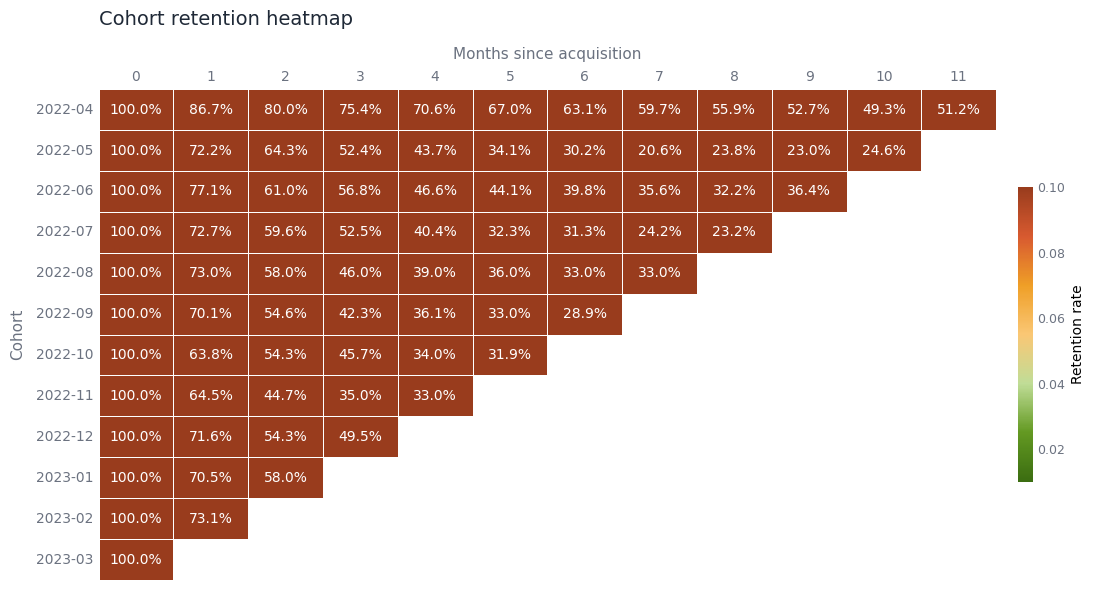

In [58]:
fig, ax = plt.subplots(figsize=(12, 6))

# Traffic light: green (low) → yellow (mid) → red/orange (high)
cmap = mcolors.LinearSegmentedColormap.from_list(
    'traffic_light', ['#3B6D11', '#639922', '#C0DD97', '#FAC775', '#EF9F27', '#D85A30', '#993C1D'], N=256
)

sns.heatmap(
    retention_pivot,
    annot=True,
    fmt='.1%',
    cmap=cmap,
    vmin=0.01,
    vmax=0.10,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 10, 'weight': '500'},
    cbar_kws={'shrink': 0.6, 'pad': 0.02, 'label': 'Retention rate'},
)

# Adaptive text: white on dark ends, dark on light mid-tones
vmin, vmax = 0.01, 0.10
for text in ax.texts:
    try:
        val = float(text.get_text().replace('%', '')) / 100
        t = (val - vmin) / (vmax - vmin)
        if t < 0.25:
            text.set_color('white')   # dark green end
        elif t > 0.75:
            text.set_color('white')   # dark red/orange end
        else:
            text.set_color('#2C2C2A') # light yellow/amber mid
    except ValueError:
        pass

ax.set_title('Cohort retention heatmap', fontsize=14, fontweight='500',
             color='#1f2937', pad=16, loc='left')
ax.set_xlabel('Months since acquisition', fontsize=11, color='#6b7280', labelpad=8)
ax.set_ylabel('Cohort', fontsize=11, color='#6b7280', labelpad=8)
ax.tick_params(axis='both', labelsize=10, colors='#6b7280', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9, colors='#6b7280', length=0)
cbar.outline.set_visible(False)
plt.tight_layout()
plt.show()

In [59]:
# calculate mean RR by ages of cohorts
mean_rr_by_cohorts = retention_pivot.mean().round(2).reset_index()
mean_rr_by_cohorts.columns = ['age', 'mean_rr']
mean_rr_by_cohorts

,age,mean_rr
0,0,1.00
1,1,0.72
2,2,0.59
3,3,0.51
4,4,0.43
5,5,0.40
6,6,0.38
7,7,0.35
8,8,0.34
9,9,0.37


In [60]:
# calculate mean RR for all ages
mean_rr_by_cohorts['mean_rr'].mean()

np.float64(0.49750000000000005)

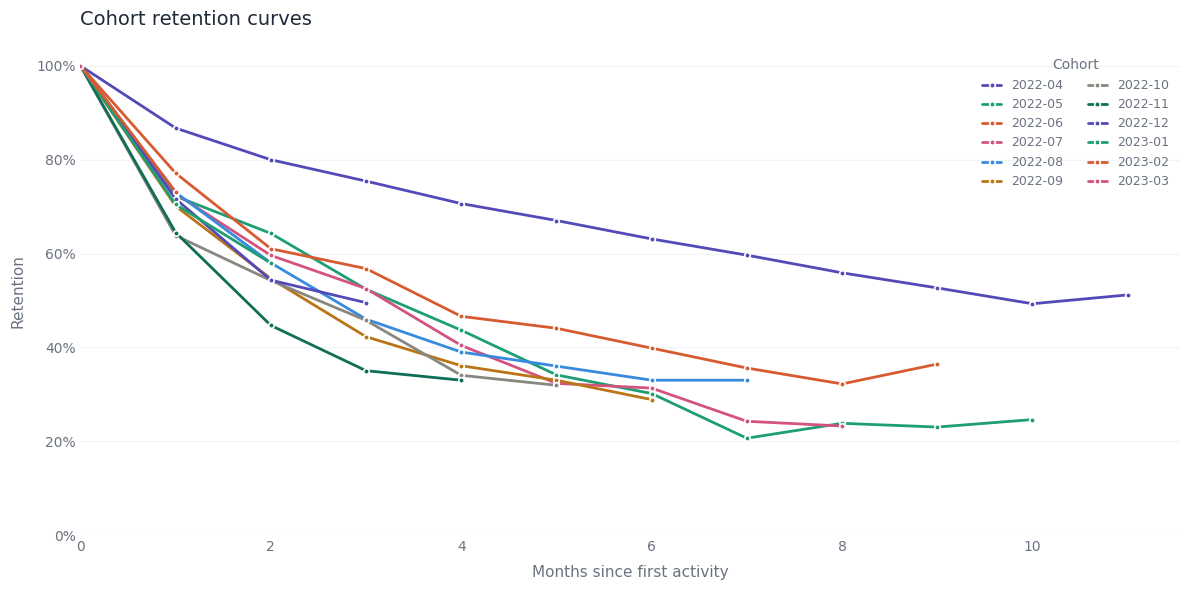

In [61]:
# Distinct palette — one hue per cohort, no repeats
palette = [
    '#534AB7', '#1D9E75', '#D85A30', '#D4537E',
    '#378ADD', '#BA7517', '#888780', '#0F6E56'
]

fig, ax = plt.subplots(figsize=(12, 6))

cohort_months = sorted(cohorts.first_activity_month.unique())

for idx, month in enumerate(cohort_months):
    subset = cohorts[cohorts['first_activity_month'] == month].sort_values('cohort_lifetime')
    color = palette[idx % len(palette)]
    ax.plot(
        subset['cohort_lifetime'],
        subset['retention'],
        color=color,
        linewidth=2,
        label=str(month),
        marker='o',
        markersize=4,
        markerfacecolor=color,
        markeredgecolor='white',
        markeredgewidth=1.2,
        solid_capstyle='round',
        solid_joinstyle='round',
    )

ax.set_title('Cohort retention curves', fontsize=14, fontweight='500',
             color='#1f2937', pad=16, loc='left')
ax.set_xlabel('Months since first activity', fontsize=11, color='#6b7280', labelpad=8)
ax.set_ylabel('Retention', fontsize=11, color='#6b7280', labelpad=8)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.tick_params(axis='both', labelsize=10, colors='#6b7280', length=0)
ax.grid(axis='y', color='#f1f5f9', linewidth=1)
ax.grid(axis='x', visible=False)
for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    title='Cohort',
    title_fontsize=10,
    fontsize=9,
    frameon=False,
    loc='upper right',
    ncol=2,
    labelcolor='#6b7280',
    handlelength=1.5,
    handleheight=0.5,
)
legend.get_title().set_color('#6b7280')

plt.tight_layout()
plt.show()

## 4.2. LTV


Notes:
- there are several approaches how to calculate LTV based on. We will calculate simple and more complex one
- We take only monthly subscriptions cause there are no users with more than 1 annual subscription

**simple calculation**

In [62]:
avg_receipt = round(df_monthly_subs['amount_paid'].mean(),2)
avg_receipt

np.float64(27.9)

In [63]:
avg_amount_purchases = round(df_monthly_subs.groupby('user_id')['invoice_id'].count().mean(),2)
avg_amount_purchases

np.float64(5.31)

In [64]:
ltv_simple = round(avg_receipt * avg_amount_purchases,2)
ltv_simple

np.float64(148.15)

**cohort calculation**

In [65]:
# find 1st purchase month and add it to the dataframe
first_activity_date = df_monthly_subs.groupby('user_id')['transaction_date'].min()
first_activity_date.name = 'first_activity_date'

In [66]:
df_monthly_subs_upd = df_monthly_subs.join(first_activity_date, on='user_id')

df_monthly_subs_upd['first_activity_month'] = pd.to_datetime(
    df_monthly_subs_upd['first_activity_date']
).dt.to_period('M')

df_monthly_subs_upd['activity_month'] = pd.to_datetime(
    df_monthly_subs_upd['transaction_date']
).dt.to_period('M')

df_monthly_subs_upd = df_monthly_subs_upd.drop(['transaction_month'], axis=1)
df_monthly_subs_upd.head()

,invoice_id,user_id,plan_id,plan_duration,transaction_date,subscription_price,discount_applied,fees_charged,amount_paid,discount_bigger_zero,first_activity_date,first_activity_month,activity_month
0,ALNtNdnZ5g,jpvAY4jgqX,3ZksraziGv,Monthly,2022-04-01,30.0,0.0,1.67,28.33,0,2022-04-01,2022-04,2022-04
1,UB/p3I3soC,7lnc9S0e+k,3ZksraziGv,Monthly,2022-04-01,30.0,0.0,1.97,28.03,0,2022-04-01,2022-04,2022-04
2,JPqaABdS9/,rSRvTF4HKP,3ZksraziGv,Monthly,2022-04-01,30.0,0.0,1.67,28.33,0,2022-04-01,2022-04,2022-04
3,qFP1t+jHi2,2P8ziCzzMW,3ZksraziGv,Monthly,2022-04-01,30.0,0.0,1.67,28.33,0,2022-04-01,2022-04,2022-04
4,/RBlpp5X7q,i677ChXxOx,3ZksraziGv,Monthly,2022-04-01,30.0,0.0,1.67,28.33,0,2022-04-01,2022-04,2022-04


In [67]:
# Calculate the number of unique users by cohorts
cohort_sizes = df_monthly_subs_upd.groupby('first_activity_month').agg({'user_id': 'nunique'}).reset_index()
cohort_sizes.columns = ['first_activity_month', 'n_buyers']
cohort_sizes

,first_activity_month,n_buyers
0,2022-04,1274
1,2022-05,126
2,2022-06,118
3,2022-07,99
4,2022-08,100
5,2022-09,97
6,2022-10,94
7,2022-11,197
8,2022-12,208
9,2023-01,176


In [68]:
# Calculate revenue by cohort in the context of the month of purchase and the first month of purchase
cohorts = df_monthly_subs_upd.groupby(['first_activity_month', 'activity_month']).agg({'amount_paid': 'sum'}).reset_index()
cohorts.head()

,first_activity_month,activity_month,amount_paid
0,2022-04,2022-04,35634.02
1,2022-04,2022-05,30845.88
2,2022-04,2022-06,28502.44
3,2022-04,2022-07,26881.45
4,2022-04,2022-08,25501.69


In [69]:
# join 2 previous tables
report = pd.merge(cohort_sizes, cohorts, on = 'first_activity_month')
report['ltv'] = report['amount_paid'] / report['n_buyers']

In [70]:
# calculate age of the cohorts and LTV
report['age'] = (report['activity_month'] - report['first_activity_month']).apply(lambda x: x.n)
report['ltv'] = report['amount_paid'] / report['n_buyers']
report.head()

,first_activity_month,n_buyers,activity_month,amount_paid,ltv,age
0,2022-04,1274,2022-04,35634.02,27.970188,0
1,2022-04,1274,2022-05,30845.88,24.211837,1
2,2022-04,1274,2022-06,28502.44,22.372402,2
3,2022-04,1274,2022-07,26881.45,21.100039,3
4,2022-04,1274,2022-08,25501.69,20.017025,4


In [71]:
# Build pivot table LTV
output = report.pivot_table(index = 'first_activity_month',
                               columns = 'age',
                               values = 'ltv',
                               aggfunc = 'mean')
output = round(output,2)

In [72]:
# Build pivot table with cumulative LTV
output_cum = output.cumsum(axis = 1)
output_cum.fillna('')

age,0,1,2,3,4,5,6,7,8,9,10,11
first_activity_month,,,,,,,,,,,,
2022-04,27.97,52.18,74.55,95.65,115.67,134.41,152.16,168.91,184.64,199.93,213.74,228.03
2022-05,26.26,46.22,64.32,78.98,91.17,100.6,108.97,114.7,121.27,127.62,134.17,
2022-06,27.32,49.07,66.33,82.46,95.75,108.23,119.56,129.69,138.89,148.88,,
2022-07,28.37,48.55,65.34,80.15,91.29,100.38,109.16,116.02,122.26,,,
2022-08,28.43,49.0,66.71,79.75,91.26,101.28,110.69,120.0,,,,
2022-09,28.16,47.81,63.16,75.03,85.23,94.57,102.69,,,,,
2022-10,28.40,46.42,61.58,74.5,84.15,93.33,,,,,,
2022-11,27.84,45.89,58.45,68.27,77.37,,,,,,,
2022-12,27.96,47.74,62.94,76.47,,,,,,,,


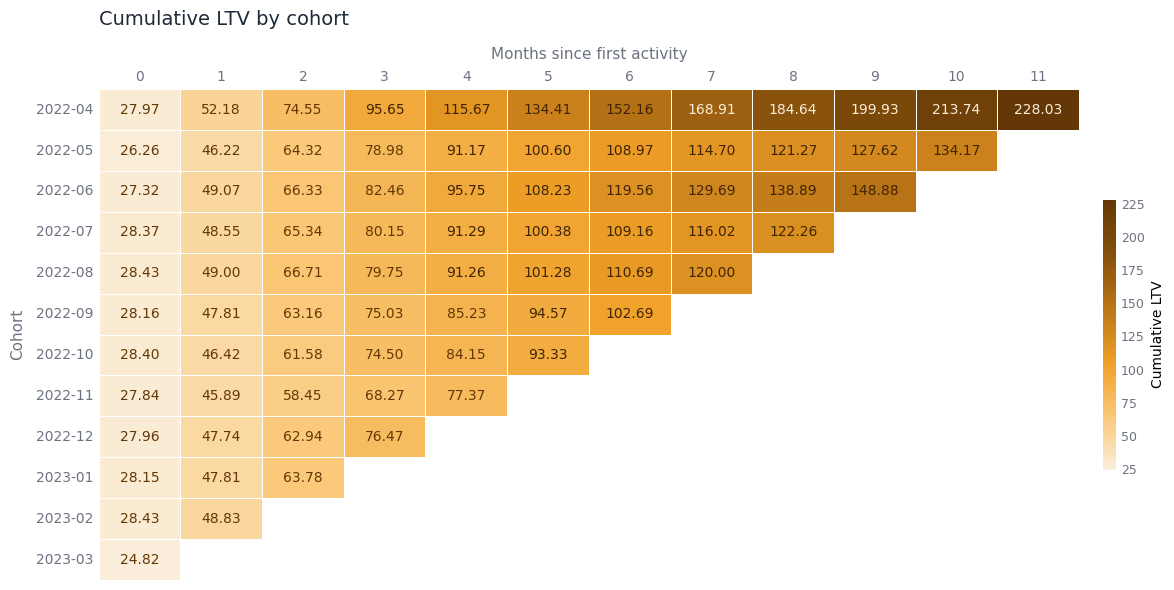

In [73]:
fig, ax = plt.subplots(figsize=(13, 6))

# Amber ramp — pale for low LTV, deep burnt amber for high
cmap = mcolors.LinearSegmentedColormap.from_list(
    'ltv_amber', ['#FAEEDA', '#FAC775', '#EF9F27', '#BA7517', '#854F0B', '#633806'], N=256
)

sns.heatmap(
    output_cum,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 10, 'weight': '500'},
    cbar_kws={'shrink': 0.55, 'pad': 0.02, 'label': 'Cumulative LTV'},
)

# Adaptive annotation colors
vmin_val = np.nanmin(output_cum.values)
vmax_val = np.nanmax(output_cum.values)

for text in ax.texts:
    try:
        val = float(text.get_text())
        t = (val - vmin_val) / (vmax_val - vmin_val)
        if t < 0.3:
            text.set_color('#633806')   # dark text on pale amber
        elif t > 0.65:
            text.set_color('#FAEEDA')   # pale text on dark amber
        else:
            text.set_color('#412402')   # darkest for mid-tones
    except ValueError:
        pass

ax.set_title('Cumulative LTV by cohort', fontsize=14, fontweight='500',
             color='#1f2937', pad=16, loc='left')
ax.set_xlabel('Months since first activity', fontsize=11, color='#6b7280', labelpad=8)
ax.set_ylabel('Cohort', fontsize=11, color='#6b7280', labelpad=8)

ax.tick_params(axis='both', labelsize=10, colors='#6b7280', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9, colors='#6b7280', length=0)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

In [74]:
# calculate mean LTV by ages of cohorts
mean_ltv_by_cohorts = output.cumsum(axis=1).mean().round(2).reset_index()
mean_ltv_by_cohorts.columns = ['age', 'mean_LTV']
mean_ltv_by_cohorts

,age,mean_LTV
0,0,27.68
1,1,48.14
2,2,64.72
3,3,79.03
4,4,91.49
5,5,104.69
6,6,117.20
7,7,129.86
8,8,141.76
9,9,158.81


In [75]:
# calculate mean LTV for all ages
round(mean_ltv_by_cohorts['mean_LTV'].mean(),2)

np.float64(113.78)

### Stage 4 Summary:
We have calculated metrics Retention and LTV:

1. The average retention rate (RR) across all cohorts for the observed period is 0.49, indicating a high retention rate.
2. However, retention starts to decrease as the cohort age increases, with the first two months being the most critical for retaining new users. During this period, almost 50% of users churn.

There are several approaches to calculate LTV for the company, ranging from optimistic to conservative and complex. In this case, we have used two popular approaches.
1. LTV increases steadily with the age of cohorts.
2. Using the basic approach (average invoices multiplied by average invoice sum), the user brings in 148 dollars for the observed period.
3. Using the cohort approach, the user brings in 113 dollars for the observed period.

# 5. Conclusions and Recomendations

We conducted an analysis of Uscreen client transactions, including subscription types, revenue, discounts, and commissions. Recommendations were developed after each analytical block.

In the first block, we prepared the data for analysis and identified duplicates, blank values, and negative fees. 
**To prevent their recurrence in the future, we recommend considering these cases.**

The second block analyzed revenue from subscriptions, discount usage, and user transitions between subscriptions. We found that over half of the revenue comes from monthly subscriptions, and a seasonal factor was observed from October to January. The share of discounted annual subscriptions decreased, while the share of monthly subscriptions sold at a discount fluctuated slightly. 
**We recommend examining transactions without commission, potentially leading to lost profits, and offer upgrades to loyal monthly subscribers between 1-6 months.**

In the third block, we calculated Retention Rate and LTV indicators. The Retention Rate was acceptable at 0.49, and the LTV was conservatively calculated at 113 dollars per user. 
**We recommend focusing on retaining new monthly subscribers during the first two months and using LTV to understand marketing spending budgets.**

### References:

- [Why cohort analysis beats all other approaches to calculating LTV](https://www.lifetimely.io/blog-posts/why-cohort-analysis-beats-all-other-approaches-to-calculating-ltv)
- [How many subscribers should you expect after one year?](https://www.revenuecat.com/blog/growth/one-year-retention-rates-insights/#:~:text=A%20retention%20rate%20is%20the,look%20like%20after%20one%20year.)
- [Correlation vs Causation: Understand the Difference for Your Product](https://amplitude.com/blog/causation-correlation)